In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [39]:
df =  pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [40]:
df.shape

(42000, 785)

In [41]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
15271,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
import matplotlib.pyplot as plt


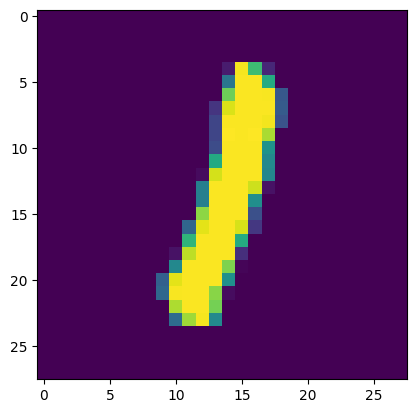

In [43]:
plt.imshow(df.iloc[3763, 1:].values.reshape(28,28))

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [46]:
y.sample()

28764    7
Name: label, dtype: int64

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
from sklearn.neighbors import KNeighborsClassifier

In [49]:
model = KNeighborsClassifier()

In [50]:
model.fit(X_train, y_train)

KNeighborsClassifier()

In [51]:
import time
start = time.time()
y_pred = model.predict(X_test)
print(time.time() - start)

10.147972106933594


In [52]:
from sklearn.metrics import accuracy_score

In [53]:
accuracy_score(y_test, y_pred)

0.9648809523809524

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
scaler = StandardScaler()

In [56]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.decomposition import PCA

In [58]:
pca = PCA(n_components=100)

In [59]:
X_train_trf = pca.fit_transform(X_train_scaled)
X_test_trf = pca.transform(X_test_scaled)

In [60]:
model = KNeighborsClassifier()

In [61]:
model.fit(X_train_trf, y_train)

KNeighborsClassifier()

In [62]:
import time
start = time.time()
y_pred = model.predict(X_test_trf)
print(time.time() - start)

1.6778695583343506


In [63]:
accuracy_score(y_test, y_pred)

0.9544047619047619